In [54]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)
np.random.seed(42)

# ML Libraries
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    f1_score,
    classification_report,
    confusion_matrix
)

import lightgbm as lgb
import xgboost as xgb


In [55]:
class Config:
    """All hyperparameters in one place - easy to modify!"""
    
    # Data
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    CV_FOLDS = 5
    
    # Feature Engineering
    TOP_N_FEATURES = 40
    
    # LightGBM
    LGB_PARAMS = {
        'n_estimators': 500,
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': 7,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 1.0,
        'reg_lambda': 1.0,
    }
    
    # XGBoost
    XGB_PARAMS = {
        'n_estimators': 500,
        'learning_rate': 0.03,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
    }

config = Config()
print(f"✅ Config loaded: {config.RANDOM_STATE}")


✅ Config loaded: 42


In [56]:
df =print("\n📥 Loading Data...")
df = pd.read_csv("novatel-customer-intelligence/train.csv")

print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['churn'].value_counts()}")
print(f"Target %: {df['churn'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum().sum()}")



📥 Loading Data...
Shape: (12000, 35)
Target distribution:
churn
0    9037
1    2963
Name: count, dtype: int64
Target %: churn
0    9037
1    2963
Name: count, dtype: int64

Missing values:
15350


In [57]:
columns_init_to_drop = ['customer_id']
# columns_init_to_drop = ['customer_id','customer_segment',
#  'region',
#  'acquisition_channel',
#  'internet_type',
#  'device_type',
#  'payment_method',
#  'promotion_type']

as_it_is = ['number_of_services','average_session_minutes','network_complaints','referral_count','referral_count']
log = ['average_session_minutes']

In [58]:

print("\n🔧 Feature Engineering...")

class FeatureEngineering:
    """Enhanced feature engineering with interactions"""
    
    def __init__(self):
        self.features_created = []
    
    def create_customer_health_score(self, df):
        """Composite health score"""
        if {"satisfaction_score", "support_calls_90d"}.issubset(df.columns):
            sat = df["satisfaction_score"].fillna(df["satisfaction_score"].median())
            calls = df["support_calls_90d"].fillna(0)
            df["customer_health_score"] = sat * 20 - calls * 2
            self.features_created.append("customer_health_score")
        return df
    
    def create_risk_segments(self, df):
        """Risk tier features"""
        if "payment_delay_days" in df.columns:
            df["payment_delay_risk"] = pd.cut(
                df["payment_delay_days"],
                bins=[-np.inf, 0.5, 2.5, np.inf],
                labels=False,
            )
            self.features_created.append("payment_delay_risk")
        return df
    
    def create_interaction_features(self, df):
        """Business interaction features"""
              
        # Engagement Score
        # if "app_sessions_weekly" in df.columns and "data_usage_gb" in df.columns:
        #     sessions_norm = df["app_sessions_weekly"] / (df["app_sessions_weekly"].max() + 1)
        #     data_norm = df["data_usage_gb"] / (df["data_usage_gb"].max() + 1)
        #     df["engagement_score"] = (sessions_norm + data_norm) / 2
        #     self.features_created.append("engagement_score")
        
        # Charge Per Service
        if {"number_of_services", "monthly_charge"}.issubset(df.columns):
            df["charge_per_service"] = (
                df["monthly_charge"] / (df["number_of_services"] + 1)
            )
            self.features_created.append("charge_per_service")

        if {"lifetime_spend", "tenure_months"}.issubset(df.columns):
            tenure_median =  df["tenure_months"].median()
            tenure = df["tenure_months"].fillna(tenure_median)
            spend = df["lifetime_spend"].fillna(0)

            df["monthly_lifetime_value"] = spend / (tenure + 1)
            self.features_created.append("monthly_lifetime_value")
        
        return df
    
    def create_binned_features(self, df):
        """Binned engagement levels"""
        # if "app_sessions_weekly" in df.columns:
        #     df["sessions_bin"] = pd.cut(
        #         df["app_sessions_weekly"],
        #         bins=[0, 3, 7, 14, 21, np.inf],
        #         labels=False
        #     )
        #     self.features_created.append("sessions_bin")

        if {"lifetime_spend", "monthly_charge"}.issubset(df.columns):
            spend = df["lifetime_spend"].fillna(0)
            charge_median = df["monthly_charge"].median()
            charge = df["monthly_charge"].fillna(charge_median)

            df["lf_calculated_tenure_months"] = spend / (charge + 1e-5)
            self.features_created.append("lf_calculated_tenure_months")

        
        return df

    def create_usage_features(self, df):
        """Create usage-related transformations."""
        if "average_session_minutes" in df.columns:
            df["average_session_log"] = np.log1p(
                df["average_session_minutes"].clip(lower=0)
            )

        if {"app_sessions_weekly", "average_session_minutes"}.issubset(
            df.columns
        ):
            sessions = df["app_sessions_weekly"].fillna(0)
            avg_minutes = df["average_session_minutes"].fillna(0)

            df["total_weekly_minutes"] = sessions * avg_minutes

        return df
    def transform(self, X):
        """Apply all transformations"""
        df = X.copy()
        df = self.create_customer_health_score(df)
        # df = self.create_risk_segments(df)
        df = self.create_interaction_features(df)
        df = self.create_binned_features(df)
        df = self.create_usage_features(df)
        return df
    
    def drop_columns_init(self, df: pd.DataFrame, drop_cols: list) -> pd.DataFrame:
            df = df.copy()
            # Drop only columns that actually exist in the dataframe to prevent KeyError
            existing_drop_cols = [col for col in drop_cols if col in df.columns]
            print("Before Shape:", df.shape)
            df = df.drop(columns=existing_drop_cols)
            print("After Shape:", df.shape)
            return df

# Apply feature engineering
fe = FeatureEngineering()
df_engineered = fe.transform(df)
df_engineered = fe.drop_columns_init(df_engineered,columns_init_to_drop)


print(f"✅ Created {len(fe.features_created)} features")
print(f"   Features: {fe.features_created}")
print("\n📊 FEATURE SUMMARY")
print("=" * 60)
print(f"Original features: {len(df.columns)}")
print(f"Final dataset shape: {df_engineered.shape}")





🔧 Feature Engineering...
Before Shape: (12000, 41)
After Shape: (12000, 40)
✅ Created 4 features
   Features: ['customer_health_score', 'charge_per_service', 'monthly_lifetime_value', 'lf_calculated_tenure_months']

📊 FEATURE SUMMARY
Original features: 35
Final dataset shape: (12000, 40)


In [59]:
df = df_engineered.copy()


In [60]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

numeric_features = [
    col for col in numeric_cols
    if col != 'churn'
]

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)


Numeric columns:
['age', 'tenure_months', 'number_of_services', 'data_usage_gb', 'streaming_hours_monthly', 'device_age_months', 'app_sessions_weekly', 'average_session_minutes', 'payment_delay_days', 'late_payment_count', 'discount_percentage', 'monthly_charge', 'network_complaints', 'support_calls_90d', 'satisfaction_score', 'referral_count', 'lifetime_spend', 'streaming_service', 'priority_support', 'autopay', 'paperless_billing', 'family_plan', 'international_plan', 'churn', 'customer_health_score', 'charge_per_service', 'monthly_lifetime_value', 'lf_calculated_tenure_months', 'average_session_log', 'total_weekly_minutes']

Categorical columns:
['customer_segment', 'region', 'acquisition_channel', 'contract_type', 'plan_tier', 'internet_type', 'device_type', 'support_plan', 'payment_method', 'promotion_type']
Numerical features: 29
['age', 'tenure_months', 'number_of_services', 'data_usage_gb', 'streaming_hours_monthly', 'device_age_months', 'app_sessions_weekly', 'average_session_

In [61]:

# Split data
X = df_engineered.drop(columns=['churn'])
y = df_engineered['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config.TEST_SIZE, 
    random_state=config.RANDOM_STATE,
    stratify=y
)


In [62]:
print("\n⚙️  Preprocessing...")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Identify column types
numeric_cols = df_engineered.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('churn')
categorical_cols = df_engineered.select_dtypes(include='object').columns.tolist()

# Ordinal columns
ordinal_cols = ['contract_type', 'plan_tier', 'support_plan']
contract_order = ['Month-to-month', 'One year', 'Two year']
plan_order = ['NovaStart', 'NovaPlus', 'NovaMax']
support_order = ['No Plan', 'NovaCare Basic', 'NovaCare Premium']

# Pipelines
# numeric_pipeline = Pipeline([
#     ("imputer", KNNImputer(n_neighbors=5)),
# ])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ohe_pipeline = Pipeline([
    # ("imputer", SimpleImputer(strategy='most_frequent')),
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first'))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ordinal", OrdinalEncoder(
        categories=[contract_order, plan_order, support_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

# Combine
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("ohe", ohe_pipeline, [c for c in categorical_cols if c not in ordinal_cols]),
    ("ordinal", ordinal_pipeline, ordinal_cols)
])

# Fit preprocessor on train, transform both
print(f"Preprocessing train/test...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert to DataFrame (for feature names)
feature_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(f"✅ Train: {X_train.shape}, Test: {X_test.shape}")



⚙️  Preprocessing...
Preprocessing train/test...
✅ Train: (9600, 65), Test: (2400, 65)


In [63]:
[c for c in categorical_cols if c not in ordinal_cols]

['customer_segment',
 'region',
 'acquisition_channel',
 'internet_type',
 'device_type',
 'payment_method',
 'promotion_type']

In [64]:

print("\n🎯 Cross-Validation Training (5-Fold)...")

skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)

cv_lgb_scores = []
cv_xgb_scores = []
cv_lgb_models = []
cv_xgb_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n  Fold {fold + 1}/{config.CV_FOLDS}...")
    
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # LightGBM
    lgb_model = lgb.LGBMClassifier(**config.LGB_PARAMS, verbosity=-1)
    lgb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    
    lgb_proba = lgb_model.predict_proba(X_fold_val)[:, 1]
    lgb_auc = roc_auc_score(y_fold_val, lgb_proba)
    cv_lgb_scores.append(lgb_auc)
    cv_lgb_models.append(lgb_model)
    print(f"    LGB AUC: {lgb_auc:.4f}")
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(**config.XGB_PARAMS, verbosity=0)
    xgb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        # early_stopping_rounds=100,
        verbose=False
    )
    
    xgb_proba = xgb_model.predict_proba(X_fold_val)[:, 1]
    xgb_auc = roc_auc_score(y_fold_val, xgb_proba)
    cv_xgb_scores.append(xgb_auc)
    cv_xgb_models.append(xgb_model)
    print(f"    XGB AUC: {xgb_auc:.4f}")

# Summary
print(f"\n✅ CV Summary:")
print(f"   LGB: {np.mean(cv_lgb_scores):.4f} ± {np.std(cv_lgb_scores):.4f}")
print(f"   XGB: {np.mean(cv_xgb_scores):.4f} ± {np.std(cv_xgb_scores):.4f}")



🎯 Cross-Validation Training (5-Fold)...

  Fold 1/5...
    LGB AUC: 0.8060
    XGB AUC: 0.8026

  Fold 2/5...
    LGB AUC: 0.8191
    XGB AUC: 0.8124

  Fold 3/5...
    LGB AUC: 0.8167
    XGB AUC: 0.8103

  Fold 4/5...
    LGB AUC: 0.8098
    XGB AUC: 0.8039

  Fold 5/5...
    LGB AUC: 0.8047
    XGB AUC: 0.8025

✅ CV Summary:
   LGB: 0.8113 ± 0.0057
   XGB: 0.8063 ± 0.0042


In [65]:
🎯 Cross-Validation Training (5-Fold)...

  Fold 1/5...
    LGB AUC: 0.8047
    XGB AUC: 0.8000

  Fold 2/5...
    LGB AUC: 0.8193
    XGB AUC: 0.8091

  Fold 3/5...
    LGB AUC: 0.8141
    XGB AUC: 0.8062

  Fold 4/5...
    LGB AUC: 0.8117
    XGB AUC: 0.8044

  Fold 5/5...
    LGB AUC: 0.8037
    XGB AUC: 0.8037

✅ CV Summary:
   LGB: 0.8107 ± 0.0059
   XGB: 0.8047 ± 0.0030

SyntaxError: invalid character '🎯' (U+1F3AF) (3149099937.py, line 1)

In [ ]:

print("\n🎁 Building Ensemble...")

# Train on full training set
lgb_final = lgb.LGBMClassifier(**config.LGB_PARAMS, verbosity=-1)
lgb_final.fit(X_train, y_train)

xgb_final = xgb.XGBClassifier(**config.XGB_PARAMS, verbosity=0)
xgb_final.fit(X_train, y_train)

# # Logistic Regression (for diversity)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


lr_final = LogisticRegression(max_iter=1000,random_state=config.RANDOM_STATE)
lr_final.fit(X_train, y_train)

# Predictions
lgb_proba = lgb_final.predict_proba(X_test)[:, 1]
xgb_proba = xgb_final.predict_proba(X_test)[:, 1]
lr_proba = lr_final.predict_proba(X_test)[:, 1]

# Ensemble average
ensemble_proba = (lgb_proba + xgb_proba + lr_proba) / 3
# ensemble_proba = (lgb_proba + xgb_proba) / 2

# Evaluate
lgb_auc = roc_auc_score(y_test, lgb_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)
lr_auc = roc_auc_score(y_test, lr_proba)
ensemble_auc = roc_auc_score(y_test, ensemble_proba)

print(f"✅ Test Set Performance:")
print(f"   LGB AUC: {lgb_auc:.4f}")
print(f"   XGB AUC: {xgb_auc:.4f}")
print(f"   LR AUC: {lr_auc:.4f}")
print(f"   🏆 Ensemble AUC: {ensemble_auc:.4f}")


🎁 Building Ensemble...
✅ Test Set Performance:
   LGB AUC: 0.7990
   XGB AUC: 0.7963
   LR AUC: 0.7883
   🏆 Ensemble AUC: 0.8016


In [ ]:
 Building Ensemble...
✅ Test Set Performance:
   LGB AUC: 0.7976
   XGB AUC: 0.7990
   LR AUC: 0.7990
   🏆 Ensemble AUC: 0.8046

NameError: name 'dfrfr' is not defined

In [68]:

print("\n🎯 Optimizing Threshold...")

def find_optimal_threshold(y_true, y_proba):
    """Find best threshold using F1 score"""
    thresholds = np.linspace(0.05, 0.95, 100)
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    return best_threshold, best_f1

optimal_threshold, optimal_f1 = find_optimal_threshold(y_test, ensemble_proba)
print(f"✅ Optimal Threshold: {optimal_threshold:.3f}")
print(f"   F1 Score: {optimal_f1:.4f}")

# Apply threshold
y_pred_optimal = (ensemble_proba >= optimal_threshold).astype(int)

# Classification report
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_optimal))


🎯 Optimizing Threshold...
✅ Optimal Threshold: 0.268
   F1 Score: 0.5661

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1807
           1       0.48      0.69      0.57       593

    accuracy                           0.74      2400
   macro avg       0.68      0.72      0.69      2400
weighted avg       0.78      0.74      0.75      2400



In [69]:
import shap

explainer = shap.TreeExplainer(lgb_final)

shap_values = explainer.shap_values(X_test)

# Handle different SHAP versions
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP": np.abs(shap_class1).mean(axis=0),
    "Importance": lgb_final.feature_importances_
}).sort_values(
    "SHAP",
    ascending=False
)

# Top 40 features
selected = feature_importance.head(40)["Feature"].tolist()

feature_importance.head(40)

,Feature,SHAP,Importance
62,ordinal__contract_type,0.844528,355
10,numeric__discount_percentage,0.239615,567
14,numeric__satisfaction_score,0.225473,738
23,numeric__customer_health_score,0.203556,636
11,numeric__monthly_charge,0.176169,924
2,numeric__number_of_services,0.146838,263
1,numeric__tenure_months,0.145796,616
24,numeric__charge_per_service,0.141814,922
12,numeric__network_complaints,0.136972,267
0,numeric__age,0.131146,835


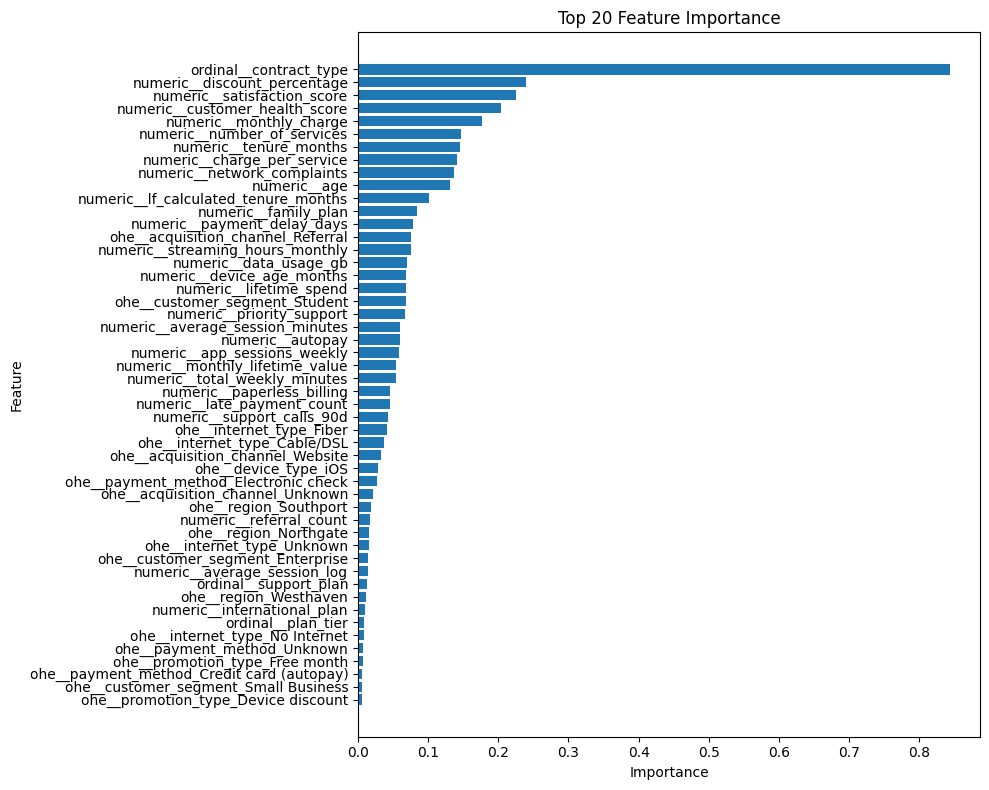

In [70]:
import matplotlib.pyplot as plt
top_features = feature_importance.head(50)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["SHAP"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")

plt.tight_layout()
plt.show()

### optuna

In [ ]:
import optuna
import numpy as np

from optuna.samplers import TPESampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score


def tune_logistic_regression(X_train, y_train, n_trials=50):

    def objective(trial):

        params = {
            "C": trial.suggest_float(
                "C", 1e-4, 100, log=True
            ),

            "penalty": trial.suggest_categorical(
                "penalty",
                ["l1", "l2"]
            ),

            "solver": trial.suggest_categorical(
                "solver",
                ["liblinear", "saga"]
            ),

            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"]
            ),

            "max_iter": trial.suggest_int('max_iter', 300, 1000),
            "random_state": 42
        }

        cv_scores = []

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        for train_idx, val_idx in skf.split(X_train, y_train):

            # Works for NumPy arrays
            X_fold_train = X_train[train_idx]
            X_fold_val = X_train[val_idx]

            y_fold_train = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
            y_fold_val = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

            model = LogisticRegression(**params)

            model.fit(
                X_fold_train,
                y_fold_train
            )

            val_proba = model.predict_proba(
                X_fold_val
            )[:, 1]

            pr_auc = average_precision_score(
                y_fold_val,
                val_proba
            )

            cv_scores.append(pr_auc)

        return np.mean(cv_scores)

    sampler = TPESampler(seed=42)

    study = optuna.create_study(
        sampler=sampler,
        direction="maximize"
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True
    )

    return study.best_params, study.best_value

lr_best_params, lr_best_score = tune_logistic_regression(
    X_train,
    y_train,
    n_trials=150
)

print(f"Best CV PR-AUC: {lr_best_score:.4f}")
print("Best Parameters:")
print(lr_best_params)

[I 2026-09-28 22:30:57,163] A new study created in memory with name: no-name-18b9deb7-b7b0-4de4-ab76-afa3c1060804
  0%|          | 0/150 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.555571:   1%|          | 1/150 [00:01<04:02,  1.63s/it]

[I 2026-09-28 22:30:58,793] Trial 0 finished with value: 0.5555707118469289 and parameters: {'C': 0.017670169402947963, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 907}. Best is trial 0 with value: 0.5555707118469289.


Best trial: 1. Best value: 0.560808:   1%|▏         | 2/150 [00:09<13:13,  5.36s/it]

[I 2026-09-28 22:31:06,767] Trial 1 finished with value: 0.5608084744397533 and parameters: {'C': 0.4042872735027334, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 428}. Best is trial 1 with value: 0.5608084744397533.


...

[I 2026-09-28 22:39:12,226] Trial 147 finished with value: 0.5632077487896814 and parameters: {'C': 0.0005012870432122009, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 518}. Best is trial 94 with value: 0.565388855631206.


Best trial: 94. Best value: 0.565389:  99%|█████████▉| 149/150 [08:15<00:00,  1.08it/s]

[I 2026-09-28 22:39:13,156] Trial 148 finished with value: 0.564589704533031 and parameters: {'C': 0.0042109324246427035, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 726}. Best is trial 94 with value: 0.565388855631206.


Best trial: 94. Best value: 0.565389: 100%|██████████| 150/150 [08:16<00:00,  3.31s/it]

[I 2026-09-28 22:39:14,155] Trial 149 finished with value: 0.5652151161098571 and parameters: {'C': 0.0016159883725577221, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 698}. Best is trial 94 with value: 0.565388855631206.
Best CV PR-AUC: 0.5654
Best Parameters:
{'C': 0.0014175136727063147, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 715}


In [71]:
lr_final = LogisticRegression(
    **lr_best_params
)

lr_final.fit(
    X_train_processed,
    y_train
)
lr_proba = lr_final.predict_proba(X_test)[:, 1]


# Evaluate
lr_auc = roc_auc_score(y_test, lr_proba)
print(f"lr AUC: {lr_auc:.4f}")

lr AUC: 0.7856


In [ ]:


def tune_with_cv_lgb(X_train, y_train, n_trials=150):
    '''Hyperparameter tuning with cross-validation'''
    
    def objective(trial):
        # Define hyperparameters to tune
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 5, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 100, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 100, log=True),
            'min_split_gain': trial.suggest_float('min_split_gain', 0, 1),
        }
        
        # Cross-validation evaluation
        cv_scores = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = lgb.LGBMClassifier(**params, verbosity=-1)
            model.fit(X_fold_train, y_fold_train,
                      eval_set=[(X_fold_val, y_fold_val)],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
            
            val_proba = model.predict_proba(X_fold_val)[:, 1]
            pr_auc = average_precision_score(y_fold_val, val_proba)
            cv_scores.append(pr_auc)
        
        return np.mean(cv_scores)
    
    # Use TPESampler for better exploration
    sampler = TPESampler(seed=42)
    study = optuna.create_study(sampler=sampler, direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    return study.best_params, study.best_value

lgb_best_params, lgb_best_score = tune_with_cv_lgb(X_train, y_train, n_trials=150)

print(f"Best PR-AUC: {lgb_best_score:.4f}")
print(f"Best Parameters: {lgb_best_params}")


[I 2026-09-28 17:24:41,816] A new study created in memory with name: no-name-cb2aa6b4-49ed-46e8-9dc5-8233105c2668
Best trial: 0. Best value: 0.593737:   1%|          | 1/150 [00:01<03:54,  1.57s/it]

[I 2026-09-28 17:24:43,388] Trial 0 finished with value: 0.593736800041466 and parameters: {'n_estimators': 562, 'learning_rate': 0.08927180304353628, 'num_leaves': 115, 'max_depth': 9, 'min_child_samples': 16, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 8.499808989183016, 'reg_lambda': 0.06440507553993717, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 0.593736800041466.


Best trial: 0. Best value: 0.593737:   1%|▏         | 2/150 [00:03<04:19,  1.75s/it]

[I 2026-09-28 17:24:45,266] Trial 1 finished with value: 0.5913386336401315 and parameters: {'n_estimators': 314, 'learning_rate': 0.09330606024425668, 'num_leaves': 129, 'max_depth': 6, 'min_child_samples': 17, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'reg_alpha': 0.01577798188336503, 'reg_lambda': 0.0028546978577971838, 'min_split_gain': 0.2912291401980419}. Best is trial 0 with value: 0.593736800041466.


Best trial: 2. Best value: 0.596988:   2%|▏         | 3/150 [00:10<09:51,  4.02s/it]

...

[I 2026-09-28 18:14:35,757] Trial 147 finished with value: 0.5997095789361774 and parameters: {'n_estimators': 877, 'learning_rate': 0.03220740953856562, 'num_leaves': 147, 'max_depth': 5, 'min_child_samples': 38, 'subsample': 0.7723910861587298, 'colsample_bytree': 0.6798403282514187, 'reg_alpha': 3.748372886538075e-06, 'reg_lambda': 0.37600456791182574, 'min_split_gain': 0.8928718886090935}. Best is trial 134 with value: 0.6029717916300206.


Best trial: 134. Best value: 0.602972:  99%|█████████▉| 149/150 [49:56<00:02,  2.64s/it]

[I 2026-09-28 18:14:38,629] Trial 148 finished with value: 0.6017727690716622 and parameters: {'n_estimators': 860, 'learning_rate': 0.02782962330510895, 'num_leaves': 141, 'max_depth': 5, 'min_child_samples': 39, 'subsample': 0.7603127283646323, 'colsample_bytree': 0.6437975637548299, 'reg_alpha': 1.2766840819828626e-05, 'reg_lambda': 0.21061957485907531, 'min_split_gain': 0.9707378984220777}. Best is trial 134 with value: 0.6029717916300206.


Best trial: 134. Best value: 0.602972: 100%|██████████| 150/150 [50:00<00:00, 20.00s/it]

[I 2026-09-28 18:14:41,869] Trial 149 finished with value: 0.599108242391618 and parameters: {'n_estimators': 843, 'learning_rate': 0.027633040816987742, 'num_leaves': 140, 'max_depth': 6, 'min_child_samples': 41, 'subsample': 0.7604495533432565, 'colsample_bytree': 0.6338580072316021, 'reg_alpha': 8.871272333956674e-06, 'reg_lambda': 0.23213926867232026, 'min_split_gain': 0.9814011653818911}. Best is trial 134 with value: 0.6029717916300206.
Best PR-AUC: 0.6030
Best Parameters: {'n_estimators': 915, 'learning_rate': 0.031044173439719228, 'num_leaves': 139, 'max_depth': 5, 'min_child_samples': 37, 'subsample': 0.7534457696737591, 'colsample_bytree': 0.6618116381506084, 'reg_alpha': 3.9370468042004416e-05, 'reg_lambda': 0.6051789513545471, 'min_split_gain': 0.5047056582090191}


In [ ]:
# 1. LightGBM Model
lgb_model = lgb.LGBMClassifier(
    **lgb_best_params,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(100)])


# Ensemble Predictions
lgb_pred = lgb_model.predict_proba(X_test)[:, 1]

# Average Ensemble

# Evaluate
lgb_auc = roc_auc_score(y_test, lgb_pred)

print(f"LGB AUC: {lgb_auc:.4f}")


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[202]	valid_0's binary_logloss: 0.437059
LGB AUC: 0.8085


In [ ]:
def tune_with_cv_xgb(X_train, y_train, n_trials=150):
    """Hyperparameter tuning for XGBoost using stratified cross-validation."""

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 5, 10),
            "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 100, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 100, log=True),
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "random_state": 42,
            "n_jobs": -1,
        }

        cv_scores = []

        skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

        for train_idx, val_idx in skf.split(X_train, y_train):

            X_fold_train = X_train.iloc[train_idx]
            X_fold_val = X_train.iloc[val_idx]

            y_fold_train = y_train.iloc[train_idx]
            y_fold_val = y_train.iloc[val_idx]

            model = xgb.XGBClassifier(**params)
            model.fit(X_fold_train,y_fold_train,eval_set=[(X_fold_val, y_fold_val)],verbose=False)
            val_proba = model.predict_proba(X_fold_val)[:, 1]
            pr_auc = average_precision_score(y_fold_val,val_proba)
            cv_scores.append(pr_auc)

        return np.mean(cv_scores)

    sampler = TPESampler(seed=42)

    study = optuna.create_study(
        sampler=sampler,
        direction="maximize"
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True
    )

    return study.best_params, study.best_value


xgb_best_params, xgb_best_score = tune_with_cv_xgb(
    X_train,
    y_train,
    n_trials=150
)

print(f"Best CV PR-AUC: {xgb_best_score:.4f}")
print("Best Parameters:")
print(xgb_best_params)

[I 2026-09-28 14:47:44,366] A new study created in memory with name: no-name-6af050e6-a4b6-4901-8790-ddc5c5bce5a9
Best trial: 0. Best value: 0.562956:   1%|          | 1/150 [00:24<1:00:20, 24.30s/it]

[I 2026-09-28 14:48:08,666] Trial 0 finished with value: 0.562955999376973 and parameters: {'n_estimators': 562, 'learning_rate': 0.08927180304353628, 'max_depth': 9, 'min_child_weight': 6.387926357773329, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 8.499808989183016, 'reg_lambda': 0.06440507553993717}. Best is trial 0 with value: 0.562955999376973.


Best trial: 1. Best value: 0.588982:   1%|▏         | 2/150 [01:11<1:33:11, 37.78s/it]

[I 2026-09-28 14:48:55,879] Trial 1 finished with value: 0.5889824784218826 and parameters: {'n_estimators': 796, 'learning_rate': 0.010485387725194618, 'max_depth': 10, 'min_child_weight': 8.491983767203795, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.9170225492671691, 'reg_alpha': 0.000271605114465485, 'reg_lambda': 0.01577798188336503}. Best is trial 1 with value: 0.5889824784218826.


Best trial: 2. Best value: 0.590429:   2%|▏         | 3/150 [01:35<1:16:38, 31.28s/it]

...

[I 2026-09-28 16:57:15,048] Trial 147 finished with value: 0.6015080056137847 and parameters: {'n_estimators': 751, 'learning_rate': 0.010064418413150658, 'max_depth': 9, 'min_child_weight': 8.817468964385, 'subsample': 0.6671267076020286, 'colsample_bytree': 0.6594913254536157, 'gamma': 4.600726092778693, 'reg_alpha': 2.400334751908937e-06, 'reg_lambda': 2.1065333488526068e-06}. Best is trial 143 with value: 0.6030914275934436.


Best trial: 143. Best value: 0.603091:  99%|█████████▉| 149/150 [2:09:52<00:22, 22.39s/it]

[I 2026-09-28 16:57:37,066] Trial 148 finished with value: 0.6020199201018499 and parameters: {'n_estimators': 736, 'learning_rate': 0.011589415578296335, 'max_depth': 9, 'min_child_weight': 9.462760392877259, 'subsample': 0.6920580074726917, 'colsample_bytree': 0.6330804422659955, 'gamma': 4.457667373217922, 'reg_alpha': 1.078827529937671e-05, 'reg_lambda': 3.267308420884611e-06}. Best is trial 143 with value: 0.6030914275934436.


Best trial: 143. Best value: 0.603091: 100%|██████████| 150/150 [2:10:16<00:00, 52.11s/it]

[I 2026-09-28 16:58:00,470] Trial 149 finished with value: 0.6017162030644772 and parameters: {'n_estimators': 710, 'learning_rate': 0.01164121466388478, 'max_depth': 9, 'min_child_weight': 9.757584285872248, 'subsample': 0.690963174004537, 'colsample_bytree': 0.633576589113342, 'gamma': 4.466218925532689, 'reg_alpha': 1.0299857303660698e-05, 'reg_lambda': 3.0090979467198477e-05}. Best is trial 143 with value: 0.6030914275934436.
Best CV PR-AUC: 0.6031
Best Parameters:
{'n_estimators': 713, 'learning_rate': 0.010407760187865456, 'max_depth': 9, 'min_child_weight': 9.269954794401169, 'subsample': 0.6614132628821436, 'colsample_bytree': 0.6354928494667921, 'gamma': 4.547455239348657, 'reg_alpha': 2.100056916510263e-06, 'reg_lambda': 2.29606847249289e-06}


In [ ]:
print(f"Best CV PR-AUC: {lgb_best_score:.4f}")
print("Best Parameters:")
print(lgb_best_params)

# Best CV PR-AUC: 0.6016
# Best Parameters:
# {'n_estimators': 300, 'learning_rate': 0.02280137508691528, 'num_leaves': 29, 'max_depth': 5, 'min_child_samples': 49, 'subsample': 0.846206597684575, 'colsample_bytree': 0.6451901688280609, 'reg_alpha': 2.7564298464502234e-05, 'reg_lambda': 3.369604128237287e-06, 'min_split_gain': 0.04227719702547083}

Best CV PR-AUC: 0.6016
Best Parameters:
{'n_estimators': 300, 'learning_rate': 0.02280137508691528, 'num_leaves': 29, 'max_depth': 5, 'min_child_samples': 49, 'subsample': 0.846206597684575, 'colsample_bytree': 0.6451901688280609, 'reg_alpha': 2.7564298464502234e-05, 'reg_lambda': 3.369604128237287e-06, 'min_split_gain': 0.04227719702547083}


In [ ]:
print(f"Best CV PR-AUC: {xgb_best_score:.4f}")
print("Best Parameters:")
print(xgb_best_params)

# Best CV PR-AUC: 0.6031
# Best Parameters:
# {'n_estimators': 713, 'learning_rate': 0.010407760187865456, 'max_depth': 9, 'min_child_weight': 9.269954794401169, 'subsample': 0.6614132628821436, 'colsample_bytree': 0.6354928494667921, 'gamma': 4.547455239348657, 'reg_alpha': 2.100056916510263e-06, 'reg_lambda': 2.29606847249289e-06}

Best CV PR-AUC: 0.6031
Best Parameters:
{'n_estimators': 713, 'learning_rate': 0.010407760187865456, 'max_depth': 9, 'min_child_weight': 9.269954794401169, 'subsample': 0.6614132628821436, 'colsample_bytree': 0.6354928494667921, 'gamma': 4.547455239348657, 'reg_alpha': 2.100056916510263e-06, 'reg_lambda': 2.29606847249289e-06}


In [ ]:
X_train.shape

(9600, 34)

In [ ]:

# 1. LightGBM Model
lgb_model = lgb.LGBMClassifier(
    **lgb_best_params,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(100)])

# 2. XGBoost Model
xgb_model = xgb.XGBClassifier(
    **xgb_best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 3. Logistic Regression (for diversity)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Ensemble Predictions
lgb_pred = lgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict_proba(X_test)[:, 1]
lr_pred = lr_model.predict_proba(X_test_scaled)[:, 1]

# Average Ensemble
ensemble_pred = (lgb_pred + xgb_pred + lr_pred) / 3

# Evaluate
lgb_auc = roc_auc_score(y_test, lgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_pred)
lr_auc = roc_auc_score(y_test, lr_pred)
ensemble_auc = roc_auc_score(y_test, ensemble_pred)

print(f"LGB AUC: {lgb_auc:.4f}")
print(f"XGB AUC: {xgb_auc:.4f}")
print(f"LR AUC: {lr_auc:.4f}")
print(f"Ensemble AUC: {ensemble_auc:.4f} ← BEST!")


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[250]	valid_0's binary_logloss: 0.439092
LGB AUC: 0.8056
XGB AUC: 0.8097
LR AUC: 0.7965
Ensemble AUC: 0.8085 ← BEST!


In [ ]:
 Building Ensemble...
✅ Test Set Performance:
   LGB AUC: 0.7976
   XGB AUC: 0.7990
   LR AUC: 0.7990
   🏆 Ensemble AUC: 0.8046